<a href="https://colab.research.google.com/github/NajwaQu/Praktikum_AI/blob/main/BAB5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Dense, Flatten

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
arial_path = '/content/drive/MyDrive/AI/Arial'
Brandish_path = '/content/drive/MyDrive/AI/Brandish'
Consolas_path = '/content/drive/MyDrive/AI/Consolas'
Didot_path = '/content/drive/MyDrive/AI/Didot'

In [6]:
arial_filenames = os.listdir('/content/drive/MyDrive/AI/Arial')
brandish_filenames = os.listdir('/content/drive/MyDrive/AI/Brandish')
consolas_filenames = os.listdir('/content/drive/MyDrive/AI/Consolas')
didot_filenames = os.listdir('/content/drive/MyDrive/AI/Didot')

arial_filenames [:5]

['Image_4643.jpg',
 'Image_4571.jpg',
 'Image_46.jpg',
 'Image_4622.jpg',
 'Image_4558.jpg']

In [7]:
def load_image(filenames, path):
    images = []
    for filename in tqdm(filenames):
        image = cv2.imread(path + '/' + filename)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        images.append(image)

    return images

In [10]:
arial_images = load_image(arial_filenames, arial_path)
brandish_images = load_image(brandish_filenames, Brandish_path)
consolas_images = load_image(consolas_filenames, Consolas_path)
didot_images = load_image(didot_filenames, Didot_path)

100%|██████████| 5000/5000 [23:28<00:00,  3.55it/s]


In [11]:
heights = []
widths = []

for image in arial_images:
    height = image.shape[0]
    width = image.shape[1]

    heights.append(height)
    widths.append(width)

print('max_h: {}, min_h: {}'.format(max(heights), min(heights)))
print('max_w: {}, min_w: {}'.format(max(widths), min(widths)))

max_h: 32, min_h: 32
max_w: 248, min_w: 30


In [12]:
def take_80_pixels(images_list):
    new_images = []
    for image in images_list:
        if image.shape[1] >= 80:
            new_images.append(image[:, :80])
        else:
            pass

    return np.array(new_images)

In [13]:
arial_80 = take_80_pixels(arial_images)
brandish_80 = take_80_pixels(brandish_images)
consolas_80 = take_80_pixels(consolas_images)
didot_80 = take_80_pixels(didot_images)

print(arial_80.shape)
print(brandish_80.shape)
print(consolas_80.shape)
print(didot_80.shape)

(4076, 32, 80)
(4028, 32, 80)
(4741, 32, 80)
(3920, 32, 80)


**PENGGABUNGAN**

In [14]:
all_images = np.append(arial_80, brandish_80, axis=0)
all_images = np.append(all_images, consolas_80, axis=0)
all_images = np.append(all_images, didot_80, axis=0)
all_images.shape

(16765, 32, 80)

In [15]:
all_images = all_images.reshape(all_images.shape[0],
                               all_images.shape[1],
                               all_images.shape[2],
                               1)

print(all_images.shape)


(16765, 32, 80, 1)


**MEMBUAT LABEL**

In [16]:
labels = [0]*len(arial_80) + \
         [1]*len(brandish_80) + \
         [2]*len(consolas_80) + \
         [3]*len(didot_80)

print(len(labels))

16765


**TRAIN-TEST SPLIT**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(all_images,
                                                    labels,
                                                    test_size=0.3,
                                                    random_state=88)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [18]:
y_train = y_train[:, np.newaxis]
y_test = y_test[:, np.newaxis]

In [20]:
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = one_hot_encoder.fit_transform(y_train)
y_test_encoded = one_hot_encoder.transform(y_test)

In [22]:
print(y_train[:5])

[[0]
 [2]
 [1]
 [3]
 [0]]


In [23]:
print(y_train_encoded[:5])

[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]]


**MODEL CNN**

In [24]:
input_shape = (all_images.shape[1],
              all_images.shape[2],
              1)

In [25]:
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu',
                 padding='same', input_shape=input_shape))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(2, 2))
model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(50, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 37440)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     3,744,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,768,170 (14.37 MB)

 Trainable params: 3,768,170 (14.37 MB)

 Non-trainable params: 0 (0.00 B)

**KOMPILASI MODEL**

In [26]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

**TRAINING**

In [29]:
history = model.fit(
    X_train,
    y_train_encoded,
    epochs=3,
    validation_data=(X_test, y_test_encoded)
)

Epoch 1/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 157s 428ms/step - accuracy: 1.0000 - loss: 7.6115e-07 - val_accuracy: 0.9998 - val_loss: 6.8374e-04
Epoch 2/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 203s 430ms/step - accuracy: 1.0000 - loss: 5.4912e-07 - val_accuracy: 0.9998 - val_loss: 7.0132e-04
Epoch 3/3
367/367 ━━━━━━━━━━━━━━━━━━━━ 156s 424ms/step - accuracy: 1.0000 - loss: 4.2060e-07 - val_accuracy: 0.9998 - val_loss: 6.9885e-04


**EVALUASI MODEL**

In [30]:
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

print(predictions)

158/158 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step
[3 0 0 ... 2 1 3]


In [32]:
y_test = y_test.reshape(y_test.shape[0])

print(y_test)

[3 0 0 ... 2 1 3]


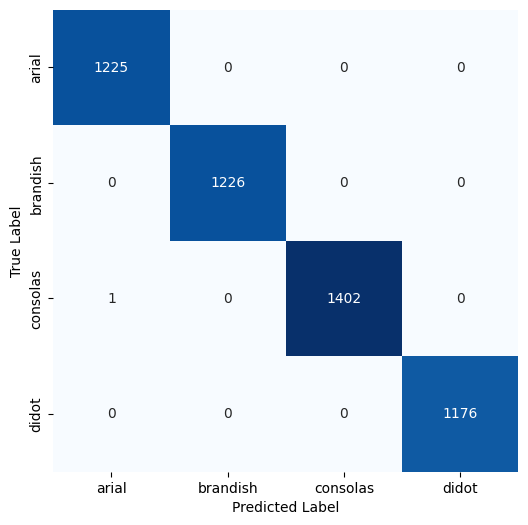

In [34]:
cm = confusion_matrix(y_test, predictions)

label_names = ['arial', 'brandish', 'consolas', 'didot']

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', cbar=False,
            xticklabels=label_names, yticklabels=label_names,
            cmap=plt.cm.Blues)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [35]:
misses = []

for i in range(len(predictions)):
    if y_test[i] != predictions[i]:
        misses.append(i)

print(misses)

[10]


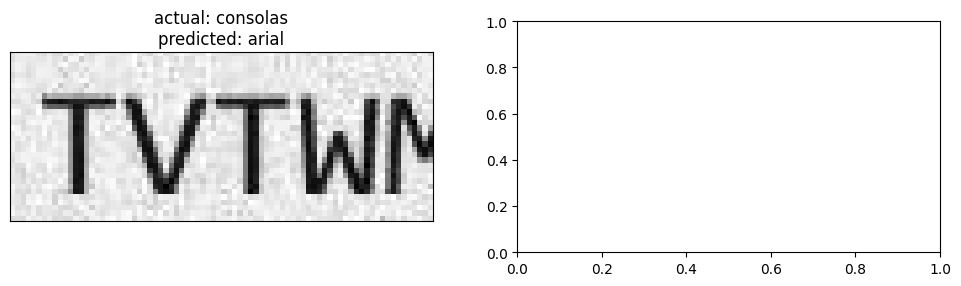

In [41]:
fig, axes = plt.subplots(ncols=2, sharex=False, figsize=(12, 3))

for i, miss in zip(range(2), misses):
    axes[i].set_title('actual: {}\npredicted: {}'.format(
        str(label_names[y_test[miss]]),
        str(label_names[predictions[miss]])
    ))

    axes[i].imshow(X_test[miss], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)

plt.show()

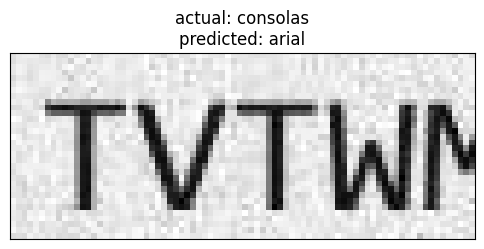

In [40]:
n_misses = len(misses)

fig, axes = plt.subplots(ncols=n_misses, sharex=False, figsize=(6 * n_misses, 3))

if n_misses == 1:
    axes = [axes]

for i, miss in enumerate(misses):
    axes[i].set_title('actual: {}\npredicted: {}'.format(
        str(label_names[y_test[miss]]),
        str(label_names[predictions[miss]])
    ))
    axes[i].imshow(X_test[miss], cmap='gray')
    axes[i].get_xaxis().set_visible(False)
    axes[i].get_yaxis().set_visible(False)

plt.show()

Berdasarkan hasil pengujian model, dapat disimpulkan bahwa model CNN yang dikembangkan memiliki performa yang sangat luar biasa dan bahkan melampaui hasil yang dicantumkan dalam buku referensi. Hal ini dibuktikan dengan hanya ditemukannya satu kesalahan prediksi (misklasifikasi) pada indeks ke-10, sementara model pada referensi mengalami dua kesalahan. Kesalahan tunggal tersebut terjadi pada gambar teks "TVTWN", di mana model memprediksi font tersebut sebagai Arial padahal label aslinya adalah Consolas.